# Heart Disease Risk Assessment (Tree-based Models)

First 5 Rows
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal   

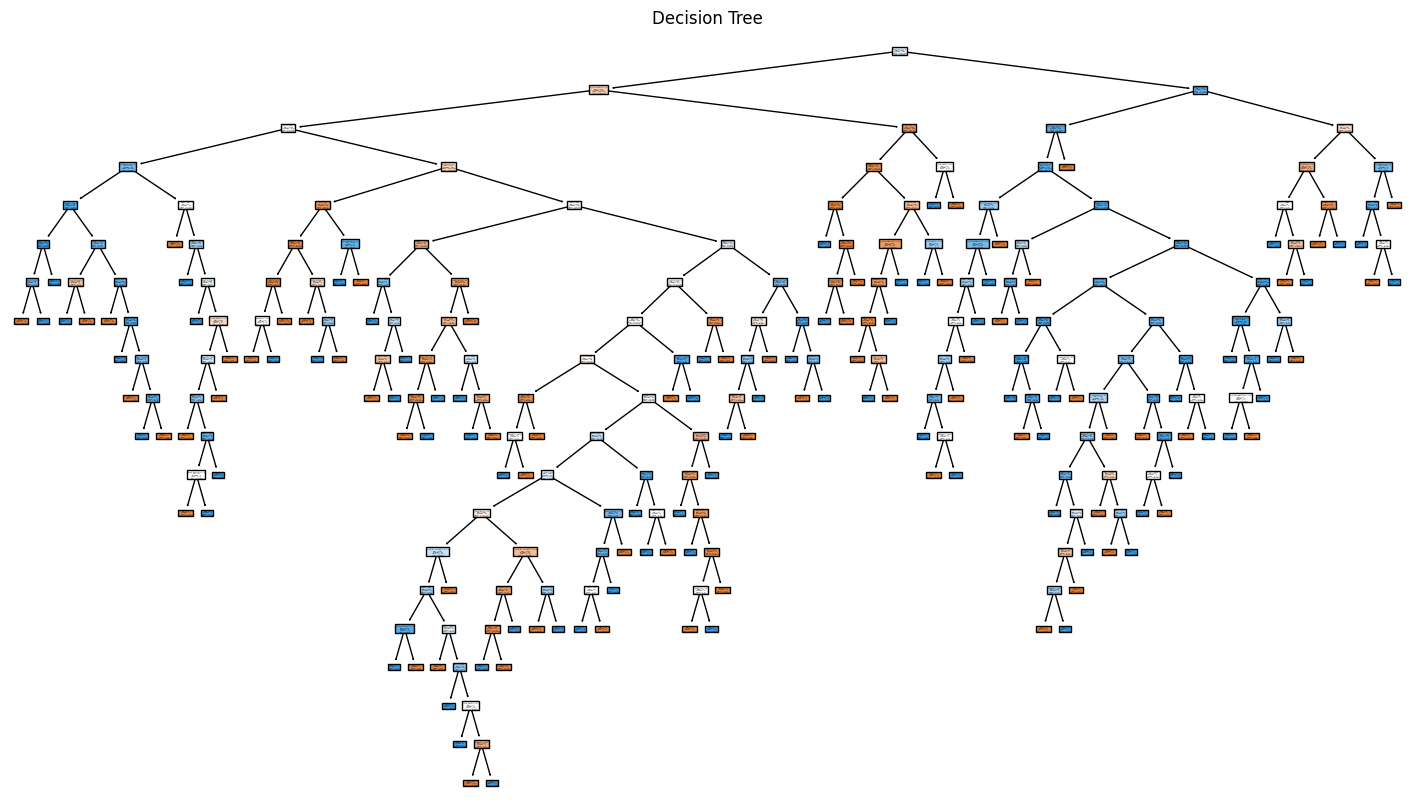


Random Forest Accuracy
0.842391304347826

Random Forest Report
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81        75
         1.0       0.88      0.85      0.87       109

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


Feature Importance
                     Feature  Importance
3                     thalch    0.127744
2                       chol    0.119900
0                        age    0.109767
4                    oldpeak    0.107296
1                   trestbps    0.082916
7         cp_atypical angina    0.078932
13                exang_True    0.074380
6                   sex_Male    0.059288
8             cp_non-anginal    0.036126
14                slope_flat    0.035972
16               thal_normal    0.034481
5                         ca    0.030433
17    thal_reversable defect    0.022412
11            r

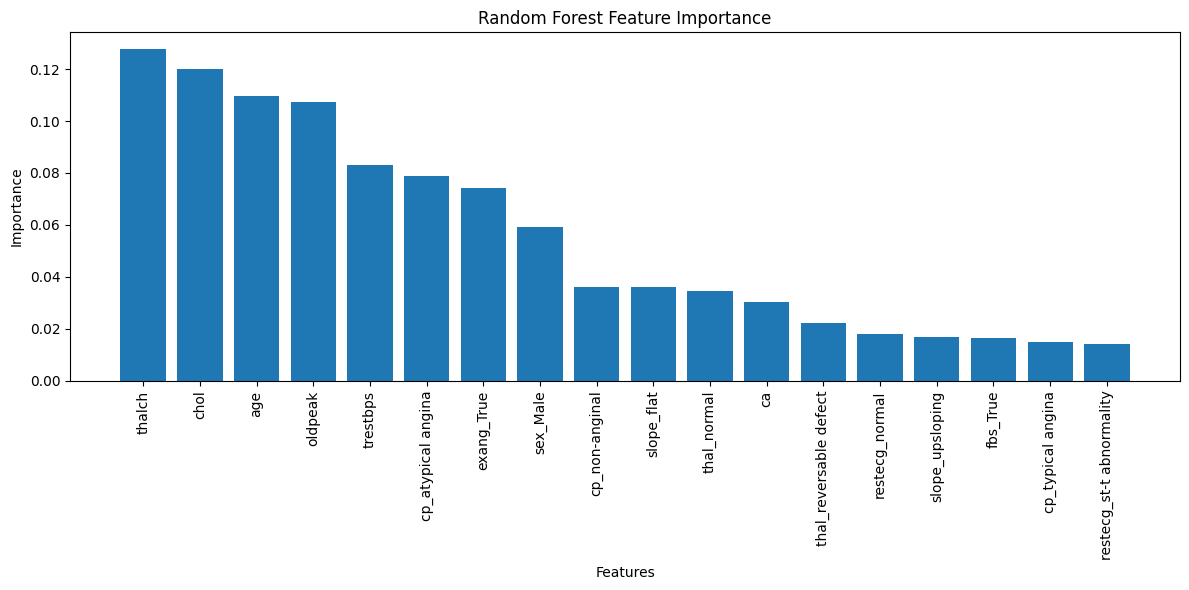


Most Important Feature:
Feature         thalch
Importance    0.127744
Name: 3, dtype: object

Least Important Feature:
Feature       restecg_st-t abnormality
Importance                    0.014069
Name: 12, dtype: object

Model Comparison
Decision Tree Accuracy : 0.7663043478260869
Random Forest Accuracy : 0.842391304347826


In [2]:

# Heart Disease Risk Assessment (UCI Dataset)


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer


# Load Dataset


df = pd.read_csv("heart_disease_uci.csv")

print("First 5 Rows")
print(df.head())


# Remove unnecessary columns


df = df.drop(columns=["id", "dataset"])


# Convert target column
# 0 = No Disease
# 1 = Disease


df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)


# Convert categorical columns into numbers


df = pd.get_dummies(df, drop_first=True)


# Handle Missing Values


imputer = SimpleImputer(strategy="most_frequent")

df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


# Split Features and Target


X = df.drop("num", axis=1)
y = df["num"]


# Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Decision Tree


dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\nDecision Tree Accuracy")
print(accuracy_score(y_test, dt_pred))

print("\nDecision Tree Report")
print(classification_report(y_test, dt_pred))


# Decision Tree Visualization


plt.figure(figsize=(18,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Disease","Disease"],
    filled=True
)

plt.title("Decision Tree")
plt.show()


# Random Forest


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRandom Forest Accuracy")
print(accuracy_score(y_test, rf_pred))

print("\nRandom Forest Report")
print(classification_report(y_test, rf_pred))


# Feature Importance


importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)


# Plot Feature Importance


plt.figure(figsize=(12,6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.show()


# Most & Least Important Feature


print("\nMost Important Feature:")
print(importance.iloc[0])

print("\nLeast Important Feature:")
print(importance.iloc[-1])


# Compare Models


print("\nModel Comparison")

print("Decision Tree Accuracy :", accuracy_score(y_test, dt_pred))

print("Random Forest Accuracy :", accuracy_score(y_test, rf_pred))